# Qwen3.8-27B W4A16 on 2× CMP 170HX (SM80) — vLLM TP2, stock checkpoint, no P2P

| Metric | Value |
|---|---|
| Decode, c=1 | **72.0 tok/s** TP2 · **103.5 tok/s** TP2 + native MTP k=3 · 54.0 tok/s TP1 (256 tokens, greedy) |
| Best aggregate | 546 tok/s at c=16 (TP1) · 535 tok/s at c=16 (TP2) |
| Prefill | 1,914 tok/s TP1 · 1,695–1,736 tok/s TP2 at 6,603 prompt tokens (prefix cache off) |
| TTFT | 3.45 s TP1 · 3.80–3.90 s TP2 at 6,603 prompt tokens |

![decode and aggregate by layout](../assets/charts/2026-10-01-qwen3.8-27b-w4a16-2card-tp2-vllm.png)

```bash
hf download dbirks/Qwen3.8-27B-W4A16-AutoRound --revision 1f05c441c4e64ae0549de44fa9ea5a6d43610314 --local-dir <weights>
```

[Model guide: Qwen3.8-27B](../docs/models/qwen3.8-27b.md)

In [1]:
# --- Status cell -------------------------------------------------------
# LIVE = False replays the committed receipts under results/<experiment>/.
# LIVE = True is not wired in this notebook: the receipts come from
# tools/serve_and_bench.sh; re-run that script to reproduce.
import os

EXPERIMENT = "2026-10-01-qwen3.8-27b-w4a16-2card-tp2-vllm"
RESULTS_DIR = os.path.join("..", "results", EXPERIMENT)
LIVE = False
print("LIVE =", LIVE, "| receipts:", RESULTS_DIR)

LIVE = False | receipts: ../results/2026-10-01-qwen3.8-27b-w4a16-2card-tp2-vllm


In [2]:
import json
from IPython.display import display, Markdown

RUNS = [
    ("tp1", "TP1 (1 card)"),
    ("tp2-same-switch", "TP2, both cards on one PLX switch"),
    ("tp2-cross-switch", "TP2, cards on different PLX switches"),
    ("tp2-cross-switch-mtp3", "TP2 cross-switch + native MTP k=3"),
]


def rp(run, name):
    return os.path.join(RESULTS_DIR, "runs", run, name)


def summaries(run):
    out = {}
    with open(rp(run, "suite.jsonl")) as f:
        for line in f:
            r = json.loads(line)
            if r.get("type") == "summary":
                out[r["case"]] = r
    return out


def table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "|" + "|".join(["---"] * len(headers)) + "|"]
    lines += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    display(Markdown("\n".join(lines)))


S = {run: summaries(run) for run, _ in RUNS}
C = {run: json.load(open(rp(run, "conc.json"))) for run, _ in RUNS}
B = {run: json.load(open(rp(run, "boot.json"))) for run, _ in RUNS}
E = {run: json.load(open(rp(run, "engine.json"))) for run, _ in RUNS}
L = {run: json.load(open(rp(run, "launch-args.json"))) for run, _ in RUNS}
T = {}
for run, _ in RUNS:
    rows = [json.loads(l) for l in open(rp(run, "suite.telemetry.jsonl"))]
    T[run] = (max(g["core_c"] for r in rows for g in r["gpus"]), max(g["power_w"] for r in rows for g in r["gpus"]),
              sorted({g["limit_w"] for r in rows for g in r["gpus"]}), sorted({(g["gen"], g["width"]) for r in rows for g in r["gpus"]}))
print("runs loaded:", list(S))

runs loaded: ['tp1', 'tp2-same-switch', 'tp2-cross-switch', 'tp2-cross-switch-mtp3']


## 1. TL;DR

**Measured.** On a host where the cards cannot use P2P (no BAR1-P2P driver patches, see the
companion interconnect notebook), vLLM falls back to NCCL for the tensor-parallel all-reduce
(`PYNCCL`; custom all-reduce needs P2P). Even so, **TP2 lifts single-stream decode from 54.0 to
72.0 tok/s (+33 %)**, and native MTP k=3 on top reaches **103.5 tok/s**. Under load the gain
disappears: at 16 concurrent streams TP2 aggregates 530–535 tok/s vs 546 on one card, and prefill
is 9–11 % slower on TP2 (every layer's all-reduce crosses host memory). MTP only pays at c=1: at c=4 it aggregates
117 tok/s vs 222 without it, and 385 vs 535 at c=16. Placing the two cards on
the same PLX switch or on different switches makes no measurable difference — without P2P
nothing uses the switch-local path. TP2 also more than doubles the KV cache (1.47–1.51 M vs
0.59 M tokens at 65,536 max length).

This is the stock `dbirks/Qwen3.8-27B-W4A16-AutoRound` checkpoint on the club's SM80 vLLM image,
**not** the DFlash2 recipe (136 tok/s on one card, different runtime and drafter); the TP1 row
here is the like-for-like control.

In [3]:
rows = []
for run, label in RUNS:
    s = S[run]
    rows.append([label, s["decode256"]["decode_tok_s"], s["decode900"]["decode_tok_s"],
                 s["prefill_long"]["prefill_tok_s"], round(s["prefill_long"]["mean_ttft_ms"] / 1000, 2),
                 max(l["aggregate_tok_s"] for l in C[run]["levels"]), E[run].get("kv_cache_tokens", "not captured"),
                 B[run]["cold_boot_s"]])
table(["Layout", "Decode 256 (tok/s)", "Decode 900 (tok/s)", "Prefill 6,603 tok (tok/s)", "TTFT 6,603 tok (s)",
       "Best aggregate, c≤16 (tok/s)", "KV cache (tokens)", "Cold boot (s)"], rows)

| Layout | Decode 256 (tok/s) | Decode 900 (tok/s) | Prefill 6,603 tok (tok/s) | TTFT 6,603 tok (s) | Best aggregate, c≤16 (tok/s) | KV cache (tokens) | Cold boot (s) |
|---|---|---|---|---|---|---|---|
| TP1 (1 card) | 53.97 | 53.35 | 1914.0 | 3.45 | 545.78 | 588317 | 323 |
| TP2, both cards on one PLX switch | 71.96 | 71.01 | 1694.7 | 3.9 | 529.7 | 1507328 | 111 |
| TP2, cards on different PLX switches | 71.88 | 71.76 | 1736.1 | 3.8 | 534.74 | 1473430 | 374 |
| TP2 cross-switch + native MTP k=3 | 103.47 | 97.56 | 1657.5 | 3.98 | 385.0 | not captured | 450 |

In [4]:
pins = [
    ("Model", "dbirks/Qwen3.8-27B-W4A16-AutoRound @ 1f05c441c4e64ae0549de44fa9ea5a6d43610314 (compressed-tensors W4A16, 8 shards)"),
    ("Runtime image", "ghcr.io/pixelml/club-170hx@sha256:62f612b49614523e6a46e1493d35d3efd1f363917129d38cc923a31053693bfb (tag vllm-glm53-sm80-pp-20260905)"),
    ("vLLM", E["tp1"]["vllm_version"]),
    ("TP all-reduce backend", E["tp2-same-switch"]["tp_allreduce_backends"]),
    ("Cards", "CMP 170HX, memory-unlocked to 64 GB; " + ", ".join(f"Gen{g} x{w}" for g, w in T["tp2-same-switch"][3])),
    ("Power limit (W)", ", ".join(str(int(x)) for x in T["tp1"][2])),
    ("Driver", "NVIDIA open 615.71.09 + host-side cmpunlocker unlock (upstream 88e39ce + BAR1-resize serialization patch)"),
    ("Topology", "two PLX PEX 8747 switches on one CPU socket; 'same switch' = GPU0+GPU1, 'cross switch' = GPU1+GPU2"),
    ("Serve flags", " ".join(L["tp2-same-switch"])),
]
table(["Pin", "Value"], pins)

| Pin | Value |
|---|---|
| Model | dbirks/Qwen3.8-27B-W4A16-AutoRound @ 1f05c441c4e64ae0549de44fa9ea5a6d43610314 (compressed-tensors W4A16, 8 shards) |
| Runtime image | ghcr.io/pixelml/club-170hx@sha256:62f612b49614523e6a46e1493d35d3efd1f363917129d38cc923a31053693bfb (tag vllm-glm53-sm80-pp-20260905) |
| vLLM | v0.1.dev20051+g487ecf187 |
| TP all-reduce backend | PYNCCL |
| Cards | CMP 170HX, memory-unlocked to 64 GB; Gen2 x16 |
| Power limit (W) | 180 |
| Driver | NVIDIA open 615.71.09 + host-side cmpunlocker unlock (upstream 88e39ce + BAR1-resize serialization patch) |
| Topology | two PLX PEX 8747 switches on one CPU socket; 'same switch' = GPU0+GPU1, 'cross switch' = GPU1+GPU2 |
| Serve flags | --model /models/Qwen3.8-27B-W4A16-AutoRound --served-model-name qwen3.8-27b --tensor-parallel-size 2 --max-model-len 65536 --gpu-memory-utilization 0.90 --max-num-seqs 32 --no-enable-prefix-caching --limit-mm-per-prompt {"image":0,"video":0} |

## 2. Visible results

### Suite (greedy, `ignore_eos`, 1 warm-up + 3 samples, mean; tokens from the final usage object)

In [5]:
rows = []
for run, label in RUNS:
    for case in ("decode256", "decode900", "prefill_long"):
        r = S[run][case]
        rows.append([label, case, r["prompt_tokens"], r["mean_completion_tokens"], r["mean_ttft_ms"], r["decode_tok_s"], r["prefill_tok_s"]])
table(["Layout", "Case", "Prompt tokens", "Completion tokens", "TTFT (ms)", "Decode (tok/s)", "Prefill (tok/s)"], rows)

| Layout | Case | Prompt tokens | Completion tokens | TTFT (ms) | Decode (tok/s) | Prefill (tok/s) |
|---|---|---|---|---|---|---|
| TP1 (1 card) | decode256 | 11 | 256.0 | 88.5 | 53.97 | 124.3 |
| TP1 (1 card) | decode900 | 11 | 900.0 | 95.2 | 53.35 | 115.5 |
| TP1 (1 card) | prefill_long | 6603 | 8.0 | 3449.9 | 52.49 | 1914.0 |
| TP2, both cards on one PLX switch | decode256 | 11 | 256.0 | 103.1 | 71.96 | 106.7 |
| TP2, both cards on one PLX switch | decode900 | 11 | 900.0 | 101.4 | 71.01 | 108.5 |
| TP2, both cards on one PLX switch | prefill_long | 6603 | 8.0 | 3896.2 | 73.39 | 1694.7 |
| TP2, cards on different PLX switches | decode256 | 11 | 256.0 | 94.1 | 71.88 | 116.9 |
| TP2, cards on different PLX switches | decode900 | 11 | 900.0 | 96.9 | 71.76 | 113.5 |
| TP2, cards on different PLX switches | prefill_long | 6603 | 8.0 | 3803.4 | 73.56 | 1736.1 |
| TP2 cross-switch + native MTP k=3 | decode256 | 11 | 256.0 | 135.6 | 103.47 | 81.1 |
| TP2 cross-switch + native MTP k=3 | decode900 | 11 | 900.0 | 133.4 | 97.56 | 82.5 |
| TP2 cross-switch + native MTP k=3 | prefill_long | 6603 | 8.0 | 3983.6 | 84.95 | 1657.5 |

### Concurrency sweep (256 output tokens, T=1.0, top_p 0.95, `ignore_eos`, 2 rounds)

In [6]:
levels = [l["concurrency"] for l in C["tp1"]["levels"]]
rows = [[c] + [next(l["aggregate_tok_s"] for l in C[run]["levels"] if l["concurrency"] == c) for run, _ in RUNS] for c in levels]
table(["Concurrency (streams)"] + [f"{label} (tok/s)" for _, label in RUNS], rows)

| Concurrency (streams) | TP1 (1 card) (tok/s) | TP2, both cards on one PLX switch (tok/s) | TP2, cards on different PLX switches (tok/s) | TP2 cross-switch + native MTP k=3 (tok/s) |
|---|---|---|---|---|
| 1 | 51.35 | 67.51 | 67.89 | 79.76 |
| 4 | 187.61 | 221.21 | 222.72 | 116.89 |
| 8 | 344.42 | 345.87 | 347.36 | 302.34 |
| 16 | 545.78 | 529.7 | 534.74 | 385.0 |

### Thermals and power during the suite (all cards in the run)

In [7]:
table(["Layout", "Peak core (°C)", "Peak power (W)", "Limit (W)"],
      [[label, T[run][0], T[run][1], ", ".join(str(int(x)) for x in T[run][2])] for run, label in RUNS])

| Layout | Peak core (°C) | Peak power (W) | Limit (W) |
|---|---|---|---|
| TP1 (1 card) | 67.0 | 187.35 | 180 |
| TP2, both cards on one PLX switch | 74.0 | 184.85 | 180 |
| TP2, cards on different PLX switches | 73.0 | 185.88 | 180 |
| TP2 cross-switch + native MTP k=3 | 70.0 | 182.8 | 180 |

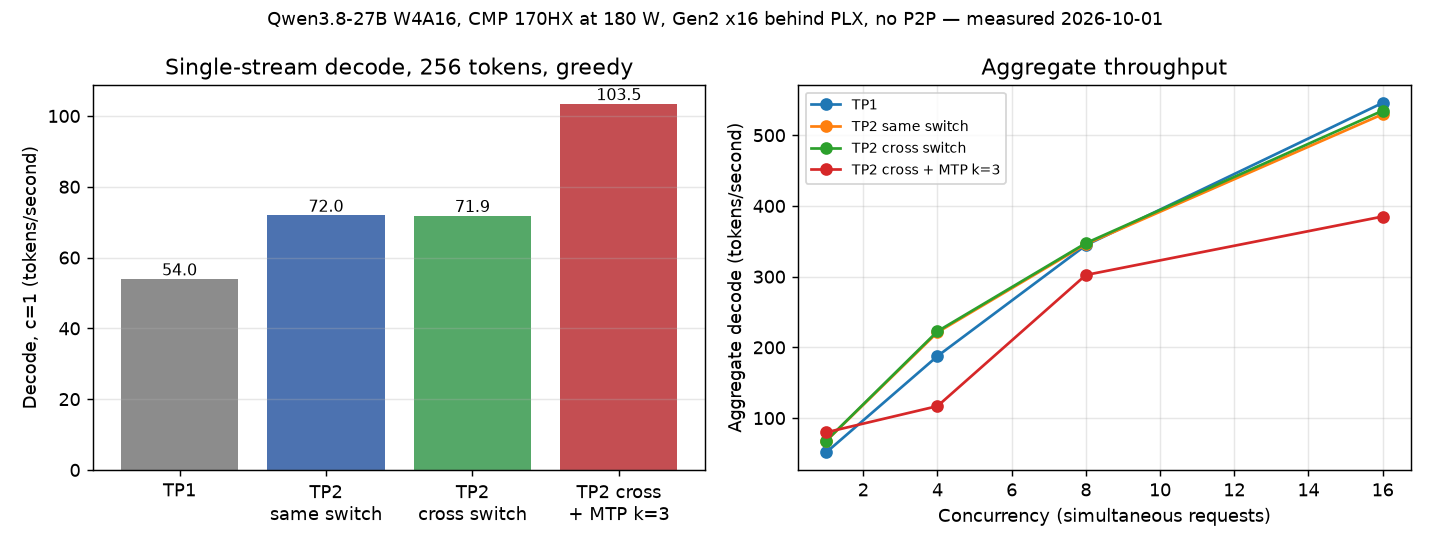

In [8]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
labels = ["TP1", "TP2\nsame switch", "TP2\ncross switch", "TP2 cross\n+ MTP k=3"]
vals = [S[run]["decode256"]["decode_tok_s"] for run, _ in RUNS]
bars = a1.bar(labels, vals, color=["#8c8c8c", "#4c72b0", "#55a868", "#c44e52"])
for b, v in zip(bars, vals):
    a1.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}", ha="center", fontsize=9)
a1.set_ylabel("Decode, c=1 (tokens/second)"); a1.set_title("Single-stream decode, 256 tokens, greedy")
a1.grid(axis="y", alpha=.3)
for (run, label), lab in zip(RUNS, labels):
    a2.plot(levels, [next(l["aggregate_tok_s"] for l in C[run]["levels"] if l["concurrency"] == c) for c in levels], marker="o", label=lab.replace("\n", " "))
a2.set_xlabel("Concurrency (simultaneous requests)"); a2.set_ylabel("Aggregate decode (tokens/second)")
a2.set_title("Aggregate throughput"); a2.grid(alpha=.3); a2.legend(fontsize=8)
fig.suptitle("Qwen3.8-27B W4A16, CMP 170HX at 180 W, Gen2 x16 behind PLX, no P2P — measured 2026-10-01", fontsize=10)
fig.tight_layout()
chart = os.path.join("..", "assets", "charts", EXPERIMENT)
fig.savefig(chart + ".png", dpi=130); fig.savefig(chart + ".svg")
plt.close(fig)
display(Image(chart + ".png"))

## 3. Reproduce

**Hardware.** Two memory-unlocked CMP 170HX (64 GB each), PCIe x16, forced airflow with live
temperature monitoring, 180 W power limit (`nvidia-smi -pl 180`). One card is enough for the
TP1 control.

```bash
hf download dbirks/Qwen3.8-27B-W4A16-AutoRound --revision 1f05c441c4e64ae0549de44fa9ea5a6d43610314 \
  --local-dir <weights>/Qwen3.8-27B-W4A16-AutoRound
docker pull ghcr.io/pixelml/club-170hx@sha256:62f612b49614523e6a46e1493d35d3efd1f363917129d38cc923a31053693bfb
docker run -d --name qwen --gpus '"device=0,1"' --ipc=host --shm-size 16g \
  -v <weights>:/models -p 127.0.0.1:18020:8000 -e VLLM_ENABLE_CUDA_COMPATIBILITY=0 ghcr.io/pixelml/club-170hx@sha256:62f612b49614523e6a46e1493d35d3efd1f363917129d38cc923a31053693bfb \
  --model /models/Qwen3.8-27B-W4A16-AutoRound --served-model-name qwen3.8-27b \
  --tensor-parallel-size 2 --max-model-len 65536 --gpu-memory-utilization 0.90 \
  --max-num-seqs 32 --no-enable-prefix-caching --limit-mm-per-prompt '{"image":0,"video":0}'
# add for MTP: --speculative-config '{"method":"mtp","num_speculative_tokens":3}'
```

Expected cold boot 5–8 min (torch.compile + CUDA graphs; ~2 min with a warm compile cache).
Bench: [`tools/serve_and_bench.sh`](../results/2026-10-01-qwen3.8-27b-w4a16-2card-tp2-vllm/tools/serve_and_bench.sh) runs the same
suite as `recipes/qwen3.8-27b-dflash2/live_benchmark.py` (decode256, decode900, 6.6k prefill)
plus [`tools/conc_sweep.py`](../results/2026-10-01-qwen3.8-27b-w4a16-2card-tp2-vllm/tools/conc_sweep.py) at c = 1/4/8/16, with a
guard that stops the server at 80 °C core or on a new Xid.

**Keep prefix caching off for the prefill case**: the suite repeats the same long prompt, and
with caching on it reports ~28,000 tok/s (cache hits, not prefill).

In [9]:
# Try your own prompt against the server started above (edit PROMPT).
import urllib.request
PROMPT = "Explain in two sentences why tensor parallelism helps single-stream decode."
URL = os.environ.get("QWEN_URL", "http://127.0.0.1:18020")
body = json.dumps({"model": "qwen3.8-27b", "messages": [{"role": "user", "content": PROMPT}],
                   "max_tokens": 256, "temperature": 0}).encode()
if LIVE:
    r = json.load(urllib.request.urlopen(urllib.request.Request(URL + "/v1/chat/completions", body, {"Content-Type": "application/json"})))
    print(r["choices"][0]["message"]["content"]); print(r["usage"])
else:
    print("LIVE = False: request not sent. Body:", body.decode())

LIVE = False: request not sent. Body: {"model": "qwen3.8-27b", "messages": [{"role": "user", "content": "Explain in two sentences why tensor parallelism helps single-stream decode."}], "max_tokens": 256, "temperature": 0}


## 4. Appendix

<details>
<summary>Thermal stops, discarded runs, limitations</summary>

- **Thermal stop on GPU0 (kept as a negative result, `runs/thermal-stop-gpu0-tp1/`).** The
  first TP1 control ran on GPU0. At the card-default 250 W it reached the 80 °C stop after
  one decode case; at 180 W with the chassis fans in a quiet profile it stopped again during
  the long prefill; with fans at full duty it completed the suite (55.2 / 53.6 tok/s decode,
  within 2 % of the GPU2 control) but hit 80 °C at c=32. That run also had prefix caching on,
  so its prefill figure is invalid. GPU0's slot has the weakest airflow in this chassis; the
  clean TP1 control ran on GPU2, and every run here used a fixed high fan duty.
- The concurrency sweep stops at c=16 for all layouts after that stop.
- MTP acceptance rate was not captured (the server log was discarded with the container).
- One run per layout; suite values are the mean of 3 samples after 1 warm-up.
- Same-switch TP2 booted in 111 s because the cross-switch run had already populated the
  compile cache; cold boots were 323–450 s.

</details>